# Amazon Sale Report — Exploratory Data Analysis

A cleaned, structured EDA covering data cleaning, univariate/bivariate analysis, outlier detection (box plots), time-series trends, and correlation analysis.

## 1. Setup

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Reusable helper so every chart doesn't repeat the same boilerplate
def plot_chart(figsize=(9, 5)):
    plt.figure(figsize=figsize)

def finish(title, xlabel=None, ylabel=None, rotate=0):
    plt.title(title, fontsize=13, fontweight="bold")
    if xlabel: plt.xlabel(xlabel)
    if ylabel: plt.ylabel(ylabel)
    if rotate: plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()


## 2. Load Data

In [3]:
try:
    df = pd.read_csv("Amazon_Sale_Report.csv")
    print(f"Loaded successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
except FileNotFoundError:
    raise FileNotFoundError("Amazon_Sale_Report.csv not found — place it in the working directory.")
except UnicodeDecodeError:
    df = pd.read_csv("Amazon_Sale_Report.csv", encoding="latin1")
    print("Loaded with latin1 encoding fallback.")

df.head()


Loaded successfully: 128,976 rows, 21 columns


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [9]:
df.shape

(128976, 21)

In [4]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel',
 'ship-service-level',
 'Category',
 'Size',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'B2B',
 'fulfilled-by',
 'New',
 'PendingS']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  str    
 2   Date                128976 non-null  str    
 3   Status              128976 non-null  str    
 4   Fulfilment          128976 non-null  str    
 5   Sales Channel       128976 non-null  str    
 6   ship-service-level  128976 non-null  str    
 7   Category            128976 non-null  str    
 8   Size                128976 non-null  str    
 9   Courier Status      128976 non-null  str    
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  str    
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  str    
 14  ship-state          128941 non-null  str    
 15  ship-postal-code    128941 non-null  float64


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,128976.0,NaN,NaN,NaN,64486.130427,37232.897832,0.0,32242.75,64486.5,96730.25,128974.0
Order ID,128976,120229,403-4984515-8861958,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,128976,91,05-03-2022,2085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,128976,13,Shipped,77815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfilment,128976,2,Amazon,89713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,128976,2,Amazon.in,128852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship-service-level,128976,2,Expedited,88630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,128976,9,T-shirt,50292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,128976,11,M,22373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Courier Status,128976,4,Shipped,109486,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

In [7]:
# Missing values before cleaning
df.isna().sum().sort_values(ascending=False)

PendingS              128976
New                   128976
fulfilled-by           89713
currency                7800
Amount                  7800
ship-state                35
ship-city                 35
ship-postal-code          35
ship-country              35
index                      0
Status                     0
Date                       0
Order ID                   0
Fulfilment                 0
Qty                        0
Courier Status             0
Size                       0
ship-service-level         0
Sales Channel              0
Category                   0
B2B                        0
dtype: int64

In [11]:
# Drop columns that are redundant or fully/near-empty in the raw export.
# errors="ignore" makes this safe even if the export format changes.
cols_to_drop = ["index", "New", "PendingS"]
existing_to_drop = [c for c in cols_to_drop if c in df.columns]
print("Dropping:", existing_to_drop)
df.drop(columns=existing_to_drop, inplace=True, errors="ignore")


Dropping: ['index', 'New', 'PendingS']


In [12]:
# Duplicate rows — report the count BEFORE removing them
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")


Duplicate rows found: 959
Shape after dropping duplicates: (128017, 18)


In [13]:
# Parse dates safely (invalid dates become NaT instead of crashing)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Years present:", sorted(df["Date"].dt.year.dropna().unique()))


Date range: 2022-03-31 00:00:00 to 2022-06-29 00:00:00
Years present: [np.int32(2022)]


In [14]:
# Location fields: fill with "Unknown" rather than a numeric statistic —
# these are categorical identifiers, not measurable quantities.
for col in ["ship-city", "ship-state", "ship-country"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Postal code is an identifier, not a number to average — cast to string
# and fill missing values with "Unknown" instead of a median value.
if "ship-postal-code" in df.columns:
    df["ship-postal-code"] = df["ship-postal-code"].astype("Int64").astype(str).replace("<NA>", "Unknown")


In [15]:
# Currency sanity check — summing Amount only makes sense if it is a single currency
if "currency" in df.columns:
    print(df["currency"].value_counts(dropna=False))


currency
INR    120454
NaN      7563
Name: count, dtype: int64


In [16]:
# Rows with missing Amount are very likely Cancelled orders with no completed
# transaction value. Report how many/why before dropping, instead of dropping silently.
missing_amount = df["Amount"].isna().sum()
pct = missing_amount / len(df) * 100
print(f"Rows with missing Amount: {missing_amount} ({pct:.2f}% of data)")
if missing_amount > 0 and "Status" in df.columns:
    print(df.loc[df["Amount"].isna(), "Status"].value_counts())

df = df.dropna(subset=["Amount"])
print(f"Shape after dropping missing Amount: {df.shape}")


Rows with missing Amount: 7563 (5.91% of data)
Status
Cancelled                       7341
Shipped                          201
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64
Shape after dropping missing Amount: (120454, 18)


In [17]:
# Final missing-value check
df.isna().sum().sort_values(ascending=False)

fulfilled-by          83217
ship-postal-code         30
Date                      0
Order ID                  0
Status                    0
Fulfilment                0
Category                  0
Size                      0
Sales Channel             0
ship-service-level        0
Qty                       0
Courier Status            0
currency                  0
Amount                    0
ship-state                0
ship-city                 0
ship-country              0
B2B                       0
dtype: int64

## 4. Feature Engineering

In [18]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df["Year"] = df["Date"].dt.year
df["Month"] = pd.Categorical(df["Date"].dt.month_name(), categories=month_order, ordered=True)
df["Weekday"] = pd.Categorical(
    df["Date"].dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    ordered=True
)

# Group by Year + Month so data spanning multiple years isn't merged together
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

df[["Date", "Year", "Month", "Weekday", "YearMonth"]].head()


,Date,Year,Month,Weekday,YearMonth
0,2022-04-30,2022,April,Saturday,2022-04
1,2022-04-30,2022,April,Saturday,2022-04
2,2022-04-30,2022,April,Saturday,2022-04
3,2022-04-30,2022,April,Saturday,2022-04
4,2022-04-30,2022,April,Saturday,2022-04


## 5. Univariate Analysis

In [19]:
df["Category"].value_counts()

Category
T-shirt     46880
Shirt       46319
Blazzer     14607
Trousers    10129
Perfume      1089
Wallet        869
Socks         411
Shoes         148
Watch           2
Name: count, dtype: int64

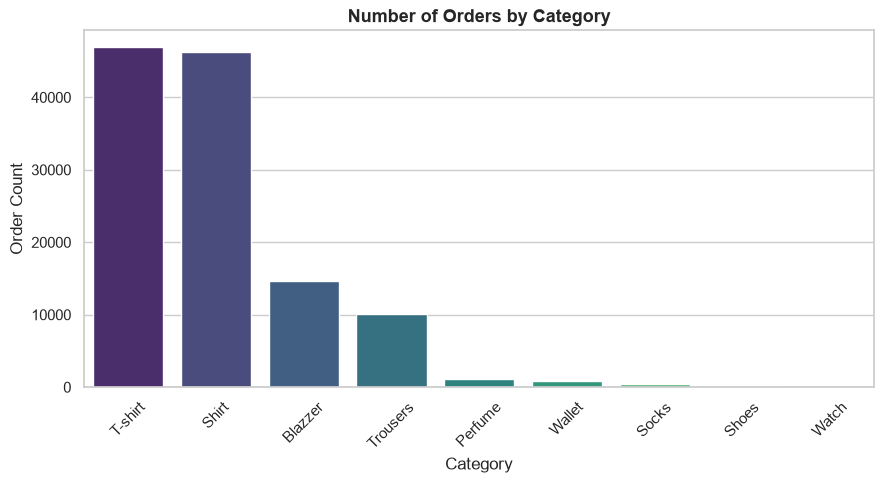

In [20]:
plot_chart((9,5))
sns.countplot(data=df, x="Category", order=df["Category"].value_counts().index, palette="viridis")
finish("Number of Orders by Category", ylabel="Order Count", rotate=45)


In [21]:
df["Status"].value_counts()

Status
Shipped                          77206
Shipped - Delivered to Buyer     28507
Cancelled                        10703
Shipped - Returned to Seller      1942
Shipped - Picked Up                970
Pending                            654
Pending - Waiting for Pick Up      277
Shipped - Returning to Seller      144
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            4
Shipped - Damaged                    1
Name: count, dtype: int64

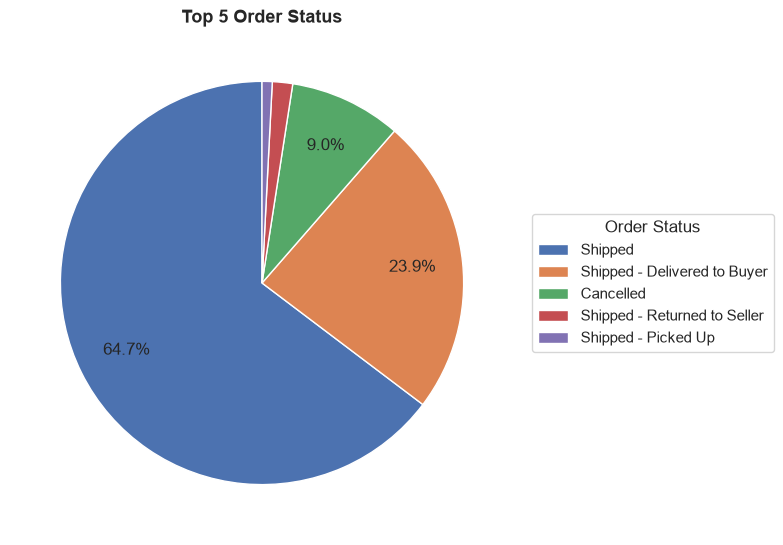

In [22]:
status = df["Status"].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    status,
    startangle=90,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    pctdistance=0.75
)
plt.legend(status.index, title="Order Status", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.title("Top 5 Order Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [23]:
df["Size"].value_counts()

Size
M       20861
L       20359
XL      19289
XXL     16688
S       15587
3XL     13799
XS      10139
Free     2108
6XL       697
5XL       525
4XL       402
Name: count, dtype: int64

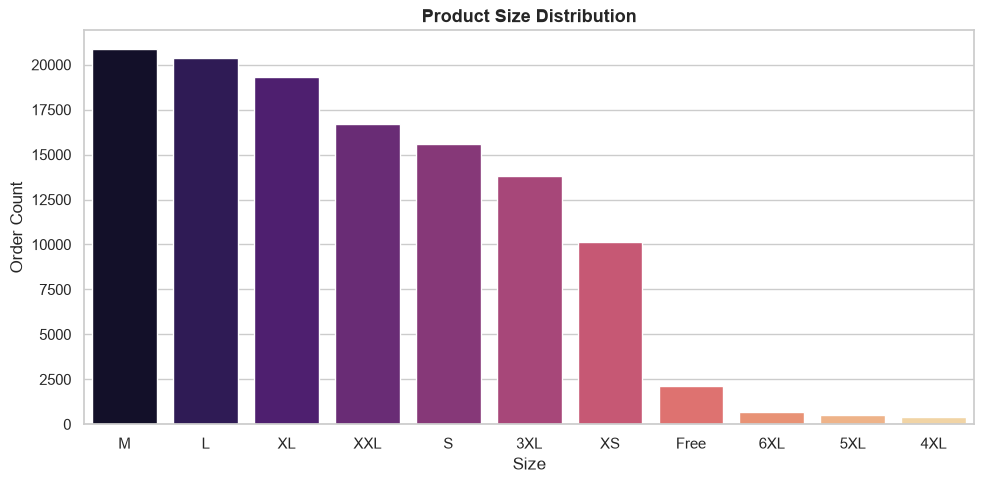

In [24]:
plot_chart((10,5))
sns.countplot(data=df, x="Size", order=df["Size"].value_counts().index, palette="magma")
finish("Product Size Distribution", ylabel="Order Count")


In [25]:
df["Fulfilment"].value_counts()

Fulfilment
Amazon      83217
Merchant    37237
Name: count, dtype: int64

## 6. Numerical Analysis (with Box Plots for outlier detection)

In [26]:
df["Qty"].describe()

count    120454.000000
mean          0.961247
std           0.214365
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           8.000000
Name: Qty, dtype: float64

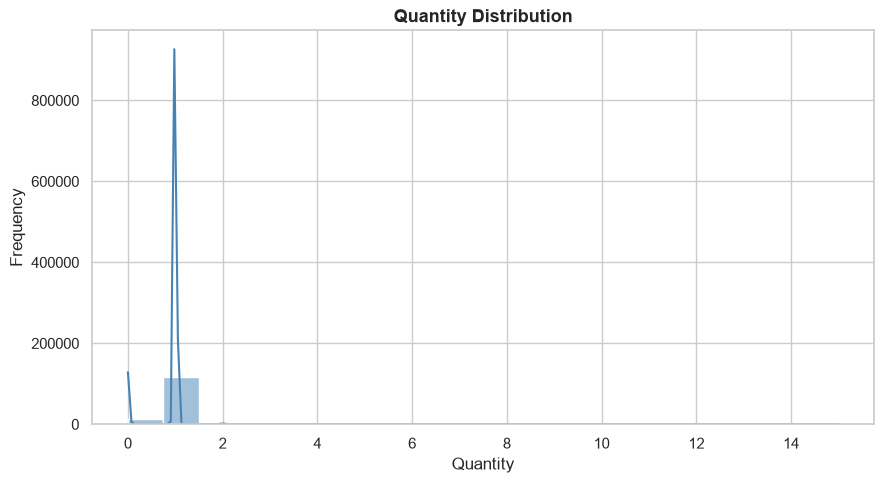

In [6]:
plot_chart()
sns.histplot(df["Qty"], bins=20, kde=True, color="steelblue")
finish("Quantity Distribution", xlabel="Quantity", ylabel="Frequency")


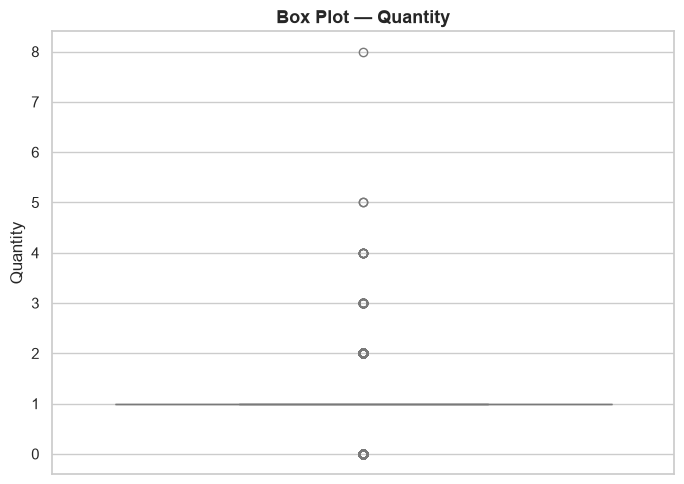

In [28]:
# Box plot: shows median, IQR, and flags outliers directly
plot_chart((7,5))
sns.boxplot(y=df["Qty"], color="lightblue")
finish("Box Plot — Quantity", ylabel="Quantity")


In [29]:
df["Amount"].describe()

count    120454.000000
mean        649.042820
std         281.415835
min           0.000000
25%         449.000000
50%         606.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

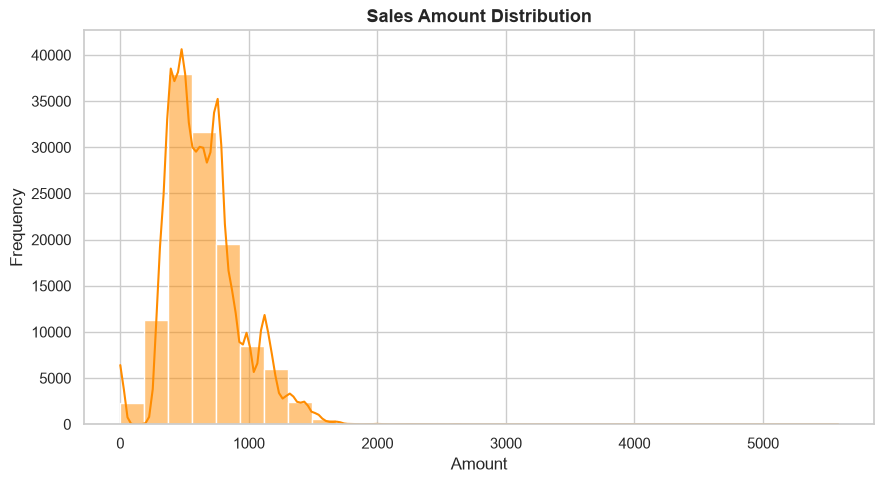

In [30]:
plot_chart()
sns.histplot(df["Amount"], bins=30, kde=True, color="darkorange")
finish("Sales Amount Distribution", xlabel="Amount", ylabel="Frequency")


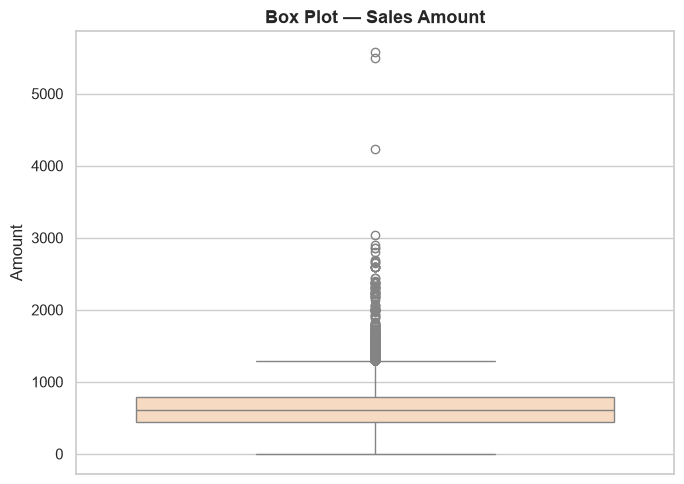

In [31]:
# Box plot for Amount — the histogram is right-skewed, so this highlights
# high-value outlier orders clearly
plot_chart((7,5))
sns.boxplot(y=df["Amount"], color="peachpuff")
finish("Box Plot — Sales Amount", ylabel="Amount")


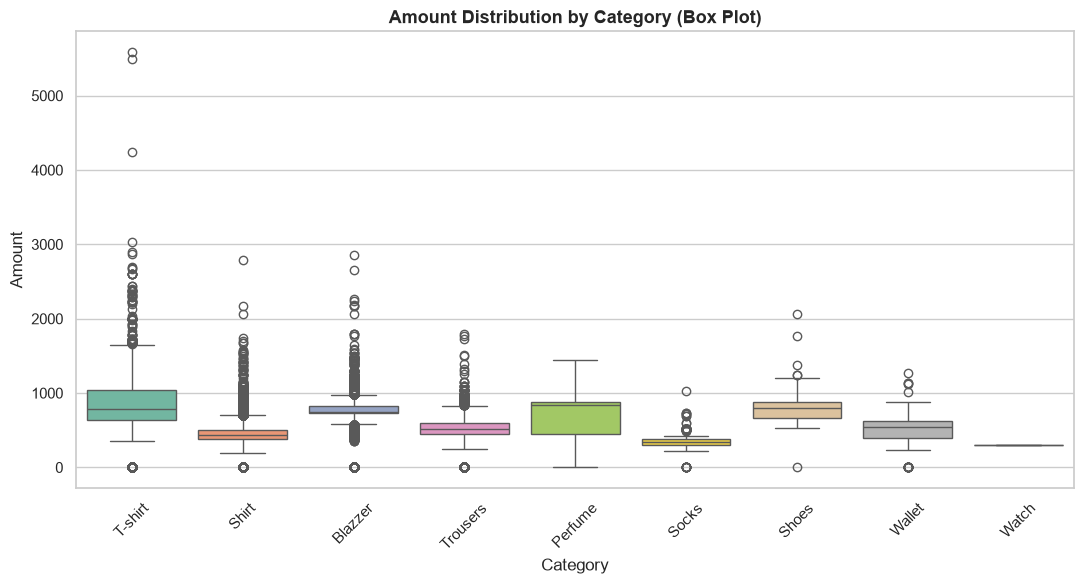

In [32]:
# Box plot of Amount split by Category — compares spread/outliers across categories
plot_chart((11,6))
sns.boxplot(data=df, x="Category", y="Amount", palette="Set2")
finish("Amount Distribution by Category (Box Plot)", ylabel="Amount", rotate=45)


In [33]:
# IQR-based outlier count — quantifies what the box plots show visually
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ["Qty", "Amount"]:
    n_out, lower, upper = iqr_outlier_count(df[col])
    print(f"{col}: {n_out} outliers outside [{lower:.2f}, {upper:.2f}] "
          f"({n_out/len(df)*100:.2f}% of orders)")


Qty: 5481 outliers outside [1.00, 1.00] (4.55% of orders)
Amount: 3594 outliers outside [-59.50, 1296.50] (2.98% of orders)


## 7. Bivariate Analysis

In [34]:
sales_category = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
sales_category

Category
T-shirt     39074570.36
Shirt       21127971.29
Blazzer     11141538.83
Trousers     5328406.30
Perfume       787818.66
Wallet        452367.18
Socks         147552.50
Shoes         118968.76
Watch            610.00
Name: Amount, dtype: float64

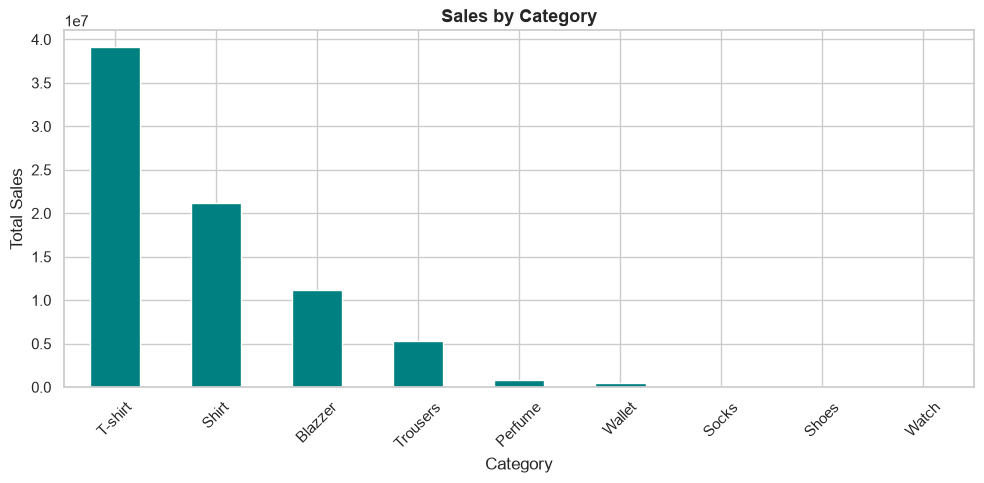

In [35]:
sales_category.plot(kind="bar", figsize=(10,5), color="teal")
plt.ylabel("Total Sales")
plt.title("Sales by Category", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:
top_state = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)
top_state

ship-state
MAHARASHTRA       13261933.90
KARNATAKA         10421496.02
TELANGANA          6880035.27
UTTAR PRADESH      6798644.08
TAMIL NADU         6477109.53
DELHI              4216456.97
KERALA             3798362.96
WEST BENGAL        3487951.01
ANDHRA PRADESH     3198443.86
HARYANA            2874244.99
Name: Amount, dtype: float64

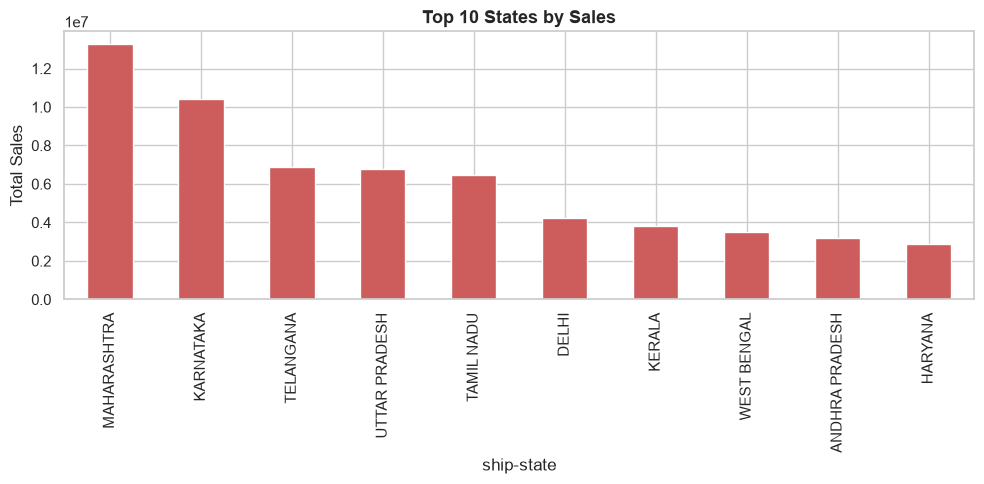

In [37]:
top_state.plot(kind="bar", figsize=(10,5), color="indianred")
plt.title("Top 10 States by Sales", fontsize=13, fontweight="bold")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


In [38]:
df["ship-city"].value_counts().head(10)

ship-city
BENGALURU    10600
HYDERABAD     7568
MUMBAI        5827
NEW DELHI     5419
CHENNAI       5103
PUNE          3644
KOLKATA       2228
GURUGRAM      1776
THANE         1600
LUCKNOW       1349
Name: count, dtype: int64

In [39]:
b2b_counts = df["B2B"].value_counts()
b2b_pct = df["B2B"].value_counts(normalize=True) * 100
pd.DataFrame({"count": b2b_counts, "pct": b2b_pct.round(2)})


,count,pct
B2B,,
False,119615,99.3
True,839,0.7


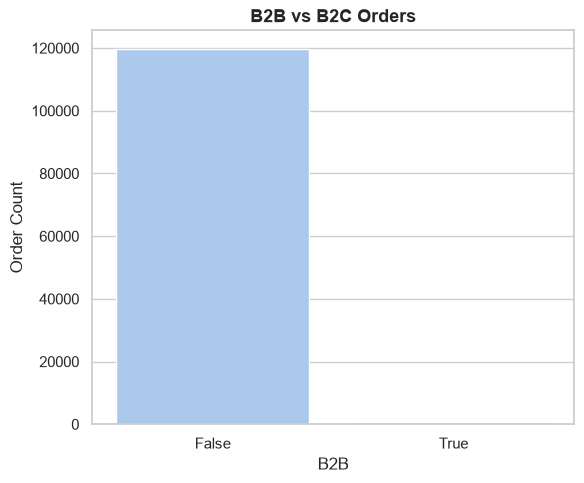

In [40]:
plot_chart((6,5))
sns.countplot(data=df, x="B2B", palette="pastel")
finish("B2B vs B2C Orders", ylabel="Order Count")


## 8. Time Series Analysis

In [41]:
monthly_sales = df.groupby("YearMonth")["Amount"].sum()
monthly_sales

YearMonth
2022-03      101683.85
2022-04    28627458.79
2022-05    26105818.34
2022-06    23344842.90
Name: Amount, dtype: float64

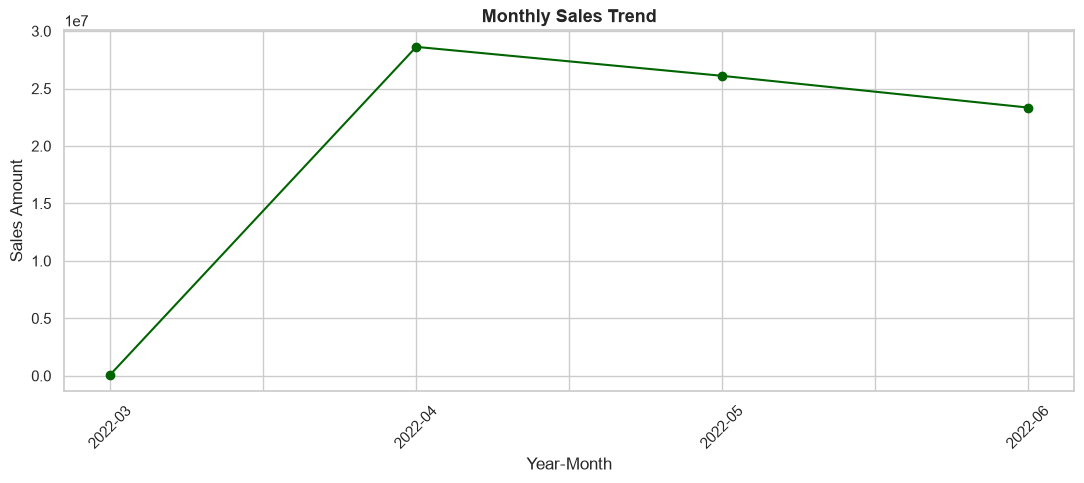

In [42]:
plot_chart((11,5))
monthly_sales.plot(marker="o", color="darkgreen")
finish("Monthly Sales Trend", xlabel="Year-Month", ylabel="Sales Amount", rotate=45)


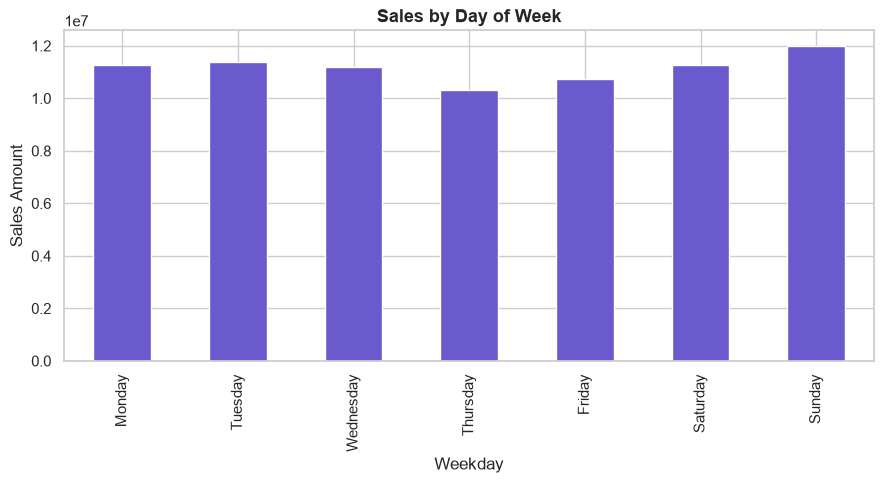

In [43]:
weekday_sales = df.groupby("Weekday")["Amount"].sum()
plot_chart((9,5))
weekday_sales.plot(kind="bar", color="slateblue")
finish("Sales by Day of Week", ylabel="Sales Amount")


## 9. Correlation Analysis

In [44]:
# Restrict to columns where correlation is analytically meaningful
# (exclude identifier-like fields such as postal code)
numeric_df = df[["Qty", "Amount"]]
numeric_df.corr()


,Qty,Amount
Qty,1.000000,0.066558
Amount,0.066558,1.000000


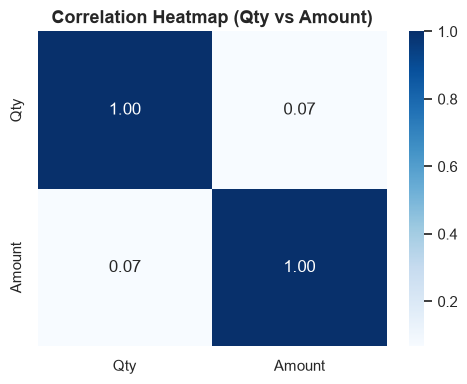

In [45]:
plot_chart((5,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
finish("Correlation Heatmap (Qty vs Amount)")


## 10. State-wise Sales Map

**Note:** `locationmode="geojson-id"` is not a valid built-in Plotly mode — Plotly's built-in `locationmode` only supports `"USA-states"` or ISO-3 country codes, not Indian states. A proper choropleth of India needs an external state-boundary GeoJSON file passed via `geojson=` and matched on a `featureidkey`. Until that file is available, the bar chart below (Section 7) is a reliable stand-in — shown here as a horizontal bar chart of all states instead of a broken map call.

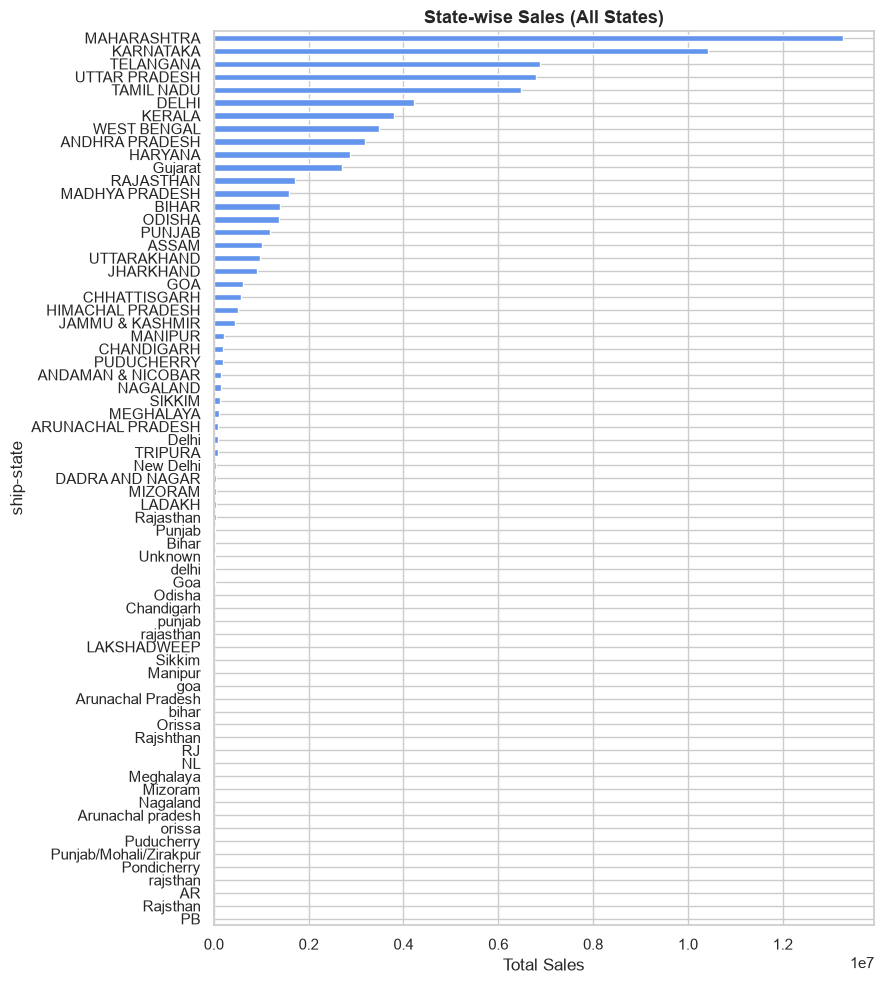

In [46]:
state_sales = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False)

plot_chart((9,10))
state_sales.plot(kind="barh", color="cornflowerblue")
plt.gca().invert_yaxis()
finish("State-wise Sales (All States)", xlabel="Total Sales")


## 11. Key Insights

_Fill in after running against your actual data — e.g._
- Top-selling category and its share of total revenue
- States/cities driving the majority of sales
- % of orders that are B2B vs B2C
- Outlier order value/quantity thresholds from the IQR analysis
- Any seasonal or day-of-week pattern in the monthly/weekday trend charts